In [2]:
!pip install nltk spacy
!python -m spacy download en_core_web_sm

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 20.8 MB/s  0:00:00
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------- ----------------- 7.9/14.2 MB 40.7 MB/s eta 0:00:01
   ---------------------------------------- 14.2/14.2 MB 37.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 38.5 MB/s  0:00:00
   ---------------------------------------- 0.0/652.5 kB ? eta -:--:--
   ---------------------------------------- 652.5/652.5 kB 26.0 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 47.1 MB/s  0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 6.2/6.2 MB 38.0 M


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -------- ------------------------------- 2.6/12.8 MB 29.9 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 41.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 38.1 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import nltk
import spacy
import matplotlib.pyplot as plt
from collections import Counter

In [4]:
matrix1 = pd.read_csv('../datos/brutos/hipotesis_3/the-matrix.csv', encoding='latin1')
matrix2 = pd.read_csv('../datos/brutos/hipotesis_3/the-matrix-reloaded.csv', encoding='latin1')
matrix3 = pd.read_csv('../datos/brutos/hipotesis_3/the-matrix-revolutions.csv', encoding='latin1')


In [5]:
matrix1.info()

<class 'pandas.DataFrame'>
RangeIndex: 622 entries, 0 to 621
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Character_Name      622 non-null    str  
 1   Character_dialogue  622 non-null    str  
dtypes: str(2)
memory usage: 9.8 KB


In [6]:
matrix2.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Character_Name      768 non-null    str  
 1   Character_dialogue  768 non-null    str  
dtypes: str(2)
memory usage: 12.1 KB


In [7]:
matrix3.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Character_Name      768 non-null    str  
 1   Character_dialogue  768 non-null    str  
dtypes: str(2)
memory usage: 12.1 KB


In [8]:
print(matrix2.equals(matrix3)) # comprueba si los dos dataframes son idénticos

False


In [10]:
print(matrix2.head(5))
print()
print(matrix3.head(5))

  Character_Name                           Character_dialogue
0        Guard 1                            See you tomorrow.
1        Guard 2                                   Oh my God.
2        Trinity                                    Iâm in.
3           Link                Sir, are you sure about this?
4       Morpheus   I told you, weâre going to be all right.

  Character_Name                         Character_dialogue
0        Guard 1                          See you tomorrow.
1        Guard 2                                 Oh my God.
2        Trinity                                    I'm in.
3           Link              Sir, are you sure about this?
4       Morpheus   I told you, we're going to be all right.


In [11]:
matrix2['Character_dialogue'] = matrix2['Character_dialogue'].str.replace('â', "'") # reemplazo caracteres corruptos por apóstrofe
matrix2.head(5) # compruebo que ha quedado bien

,Character_Name,Character_dialogue
0,Guard 1,See you tomorrow.
1,Guard 2,Oh my God.
2,Trinity,I'm in.
3,Link,"Sir, are you sure about this?"
4,Morpheus,"I told you, we're going to be all right."


In [12]:
matrix2 = pd.read_csv('../datos/brutos/hipotesis_3/the-matrix-reloaded.csv', encoding='windows-1252') # encoding que maneja bien los apóstrofes
matrix2.head(5)

,Character_Name,Character_dialogue
0,Guard 1,See you tomorrow.
1,Guard 2,Oh my God.
2,Trinity,Iâ€™m in.
3,Link,"Sir, are you sure about this?"
4,Morpheus,"I told you, weâ€™re going to be all right."


In [15]:
pip install chardet 

   ---------------------------------------- 0.0/944.0 kB ? eta -:--:--
   ---------------------------------------- 944.0/944.0 kB 22.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import chardet

with open('../datos/brutos/hipotesis_3/the-matrix-reloaded.csv', 'rb') as f: # abrimos el archivo en modo binario
    resultado = chardet.detect(f.read()) # detectamos el encoding
    
print(resultado) # vemos qué encoding sugiere

{'encoding': 'utf-8', 'confidence': 0.8300295475174292, 'language': 'en', 'mime_type': 'text/plain'}


In [17]:
matrix2 = pd.read_csv('../datos/brutos/hipotesis_3/the-matrix-reloaded.csv', encoding='utf-8', encoding_errors='replace') # reemplaza caracteres que no pueda leer
matrix2['Character_dialogue'] = matrix2['Character_dialogue'].str.replace('â\x80\x99', "'") # limpio apóstrofes corruptos
matrix2.head(5)

,Character_Name,Character_dialogue
0,Guard 1,See you tomorrow.
1,Guard 2,Oh my God.
2,Trinity,I’m in.
3,Link,"Sir, are you sure about this?"
4,Morpheus,"I told you, we’re going to be all right."


In [18]:
matrix3.head(5) # compruebo que matrix3 no tiene caracteres corruptos

,Character_Name,Character_dialogue
0,Guard 1,See you tomorrow.
1,Guard 2,Oh my God.
2,Trinity,I'm in.
3,Link,"Sir, are you sure about this?"
4,Morpheus,"I told you, we're going to be all right."


In [19]:
matrix1['num_palabras'] = matrix1['Character_dialogue'].str.split().str.len() # cuento palabras por frase dividiendo por espacios
matrix2['num_palabras'] = matrix2['Character_dialogue'].str.split().str.len()
matrix3['num_palabras'] = matrix3['Character_dialogue'].str.split().str.len()

print("Media palabras por frase Matrix 1:", matrix1['num_palabras'].mean().round(2))
print("Media palabras por frase Matrix 2:", matrix2['num_palabras'].mean().round(2))
print("Media palabras por frase Matrix 3:", matrix3['num_palabras'].mean().round(2))

Media palabras por frase Matrix 1: 11.76
Media palabras por frase Matrix 2: 10.39
Media palabras por frase Matrix 3: 10.39


In [20]:
vocab1 = matrix1['Character_dialogue'].str.cat(sep=' ').lower().split() # uno todos los diálogos y separo por palabras
vocab2 = matrix2['Character_dialogue'].str.cat(sep=' ').lower().split()
vocab3 = matrix3['Character_dialogue'].str.cat(sep=' ').lower().split()

print("Total palabras Matrix 1:", len(vocab1))
print("Palabras únicas Matrix 1:", len(set(vocab1)))
print()
print("Total palabras Matrix 2:", len(vocab2))
print("Palabras únicas Matrix 2:", len(set(vocab2)))
print()
print("Total palabras Matrix 3:", len(vocab3))
print("Palabras únicas Matrix 3:", len(set(vocab3)))

Total palabras Matrix 1: 7312
Palabras únicas Matrix 1: 1833

Total palabras Matrix 2: 7980
Palabras únicas Matrix 2: 2091

Total palabras Matrix 3: 7980
Palabras únicas Matrix 3: 2076


In [21]:
riqueza1 = len(set(vocab1)) / len(vocab1) * 100 # porcentaje de palabras únicas sobre el total
riqueza2 = len(set(vocab2)) / len(vocab2) * 100
riqueza3 = len(set(vocab3)) / len(vocab3) * 100

print(f"Riqueza léxica Matrix 1: {riqueza1:.1f}%")
print(f"Riqueza léxica Matrix 2: {riqueza2:.1f}%")
print(f"Riqueza léxica Matrix 3: {riqueza3:.1f}%")

Riqueza léxica Matrix 1: 25.1%
Riqueza léxica Matrix 2: 26.2%
Riqueza léxica Matrix 3: 26.0%


In [22]:
import nltk
nltk.download('stopwords') # descargo la lista de palabras vacías en inglés
nltk.download('punkt') # descargo el tokenizador de frases

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english')) # cargo las palabras vacías en inglés

vocab1_limpio = [w for w in vocab1 if w not in stop_words and w.isalpha()] # elimino stopwords y puntuación
vocab2_limpio = [w for w in vocab2 if w not in stop_words and w.isalpha()]
vocab3_limpio = [w for w in vocab3 if w not in stop_words and w.isalpha()]

riqueza1 = len(set(vocab1_limpio)) / len(vocab1_limpio) * 100
riqueza2 = len(set(vocab2_limpio)) / len(vocab2_limpio) * 100
riqueza3 = len(set(vocab3_limpio)) / len(vocab3_limpio) * 100

print(f"Riqueza léxica Matrix 1 (sin stopwords): {riqueza1:.1f}%")
print(f"Riqueza léxica Matrix 2 (sin stopwords): {riqueza2:.1f}%")
print(f"Riqueza léxica Matrix 3 (sin stopwords): {riqueza3:.1f}%")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rober\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rober\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Riqueza léxica Matrix 1 (sin stopwords): 41.2%
Riqueza léxica Matrix 2 (sin stopwords): 43.4%
Riqueza léxica Matrix 3 (sin stopwords): 43.6%


In [23]:
from collections import Counter

palabras_frecuentes1 = Counter(vocab1_limpio).most_common(10) # las 10 palabras más frecuentes de cada película
palabras_frecuentes2 = Counter(vocab2_limpio).most_common(10)
palabras_frecuentes3 = Counter(vocab3_limpio).most_common(10)

print("=== Matrix 1 ===")
for palabra, count in palabras_frecuentes1:
    print(f"  {palabra}: {count}")

print("\n=== Matrix 2 ===")
for palabra, count in palabras_frecuentes2:
    print(f"  {palabra}: {count}")

print("\n=== Matrix 3 ===")
for palabra, count in palabras_frecuentes3:
    print(f"  {palabra}: {count}")

=== Matrix 1 ===
  know: 49
  going: 42
  get: 28
  like: 27
  one: 25
  believe: 24
  got: 23
  want: 23
  tell: 22
  see: 18

=== Matrix 2 ===
  one: 38
  know: 30
  like: 27
  get: 22
  see: 21
  believe: 21
  gonna: 18
  come: 18
  something: 16
  must: 15

=== Matrix 3 ===
  one: 38
  know: 30
  like: 27
  get: 22
  see: 21
  believe: 21
  gonna: 18
  come: 18
  us: 16
  something: 16


### Problema!!! El csv de la 2 y la 3 es el mismo, tengo que buscar el guion de la tercera!!

In [24]:
pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import requests
from bs4 import BeautifulSoup

url = "https://www.matrixfans.net/movies/the-matrix-revolutions/transcript/"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'} # simulo ser un navegador

respuesta = requests.get(url, headers=headers) # descargo el HTML de la página
sopa = BeautifulSoup(respuesta.content, 'html.parser') # parseo el HTML

print(respuesta.status_code) # compruebo que la petición ha sido exitosa (200 = OK)
print(sopa.prettify()[:500]) # muestro los primeros 500 caracteres del HTML para ver la estructura

200
<!DOCTYPE html>
<html class="no-js mh-one-sb" lang="en-US">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1.0" name="viewport"/>
  <link href="https://gmpg.org/xfn/11" rel="profile"/>
  <link href="https://www.matrixfans.net/xmlrpc.php" rel="pingback"/>
  <meta content="index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1" name="robots">
   <!-- This site is optimized with the Yoast SEO plugin v27.5 - https://yoast.com/product/yoast-


In [29]:
print(sopa.prettify()[500:2000]) # miro más HTML para encontrar la estructura de los diálogos

seo-wordpress/ -->
   <title>
    The Matrix Revolutions Transcript - Matrix Fans
   </title>
   <link href="https://www.matrixfans.net/movies/the-matrix-revolutions/transcript/" rel="canonical"/>
   <meta content="en_US" property="og:locale">
    <meta content="article" property="og:type"/>
    <meta content="The Matrix Revolutions Transcript - Matrix Fans" property="og:title"/>
    <meta content="(The Hammer: main deck) AK: I got nothing, sir. No sign of Niobe or Ghost. Nothin’ but blue pills. Mauser: Should we jack in and try to contact them? Roland: It wouldn’t matter. My gut [...]" property="og:description"/>
    <meta content="https://www.matrixfans.net/movies/the-matrix-revolutions/transcript/" property="og:url"/>
    <meta content="Matrix Fans" property="og:site_name"/>
    <meta content="2021-08-26T04:41:45+00:00" property="article:modified_time"/>
    <meta content="https://www.matrixfans.net/wp-content/uploads/2012/01/matrix_revolutions_ver7.jpg" property="og:image"/>
    <m

In [30]:
contenido = sopa.find('div', class_='entry-content') # busco el div principal donde suelen estar los artículos en WordPress
print(contenido.prettify()[:1000]) # miro los primeros 1000 caracteres

<div class="entry-content clearfix">
 <p>
  (The Hammer: main deck)
  <br/>
  AK: I got nothing, sir. No sign of Niobe or Ghost. Nothin’ but blue pills.
  <br/>
  Mauser: Should we jack in and try to contact them?
  <br/>
  Roland: It wouldn’t matter. My gut says they’re down.
  <br/>
  Mauser: Then we should start back.
  <br/>
  Roland: No. If that ship can still fly, then we need it.
  <br/>
  Mauser: I was afraid you were gonna say that.
  <br/>
  Roland: Search every pipe, every hole, every crack we know. Sweep as wide as possible, as fast as possible.
  <br/>
  AK: Captain, these lines are crawling with calamari.
  <br/>
  Roland: Then the sooner we find them the better.
 </p>
 <p>
  (The Hammer: infirmary)
  <br/>
  Maggie: Thought you could use something to eat.
  <br/>
  Trinity: Thank you.
  <br/>
  Maggie: Any change?
  <br/>
  Trinity: No. How’s he?
  <br/>
  Maggie: He’s going to be fine, at least until he wakes up.
  <br/>
  Trinity: What do you mean?
  <br/>
  Maggie: Th

In [31]:
lineas = contenido.get_text(separator='\n').split('\n') # extraigo el texto separado por saltos de línea
lineas = [l.strip() for l in lineas if ':' in l and l.strip()] # me quedo solo con líneas que tengan el formato "Personaje: Diálogo"

filas = []
for linea in lineas:
    partes = linea.split(':', 1) # separo por los dos puntos, solo el primero
    if len(partes) == 2:
        filas.append({'Character_Name': partes[0].strip(), 'Character_dialogue': partes[1].strip()})

matrix3 = pd.DataFrame(filas) # creo el dataframe con el mismo formato que los otros
print(matrix3.shape)
matrix3.head(10)

(830, 2)


,Character_Name,Character_dialogue
0,(The Hammer,main deck)
1,AK,"I got nothing, sir. No sign of Niobe or Ghost...."
2,Mauser,Should we jack in and try to contact them?
3,Roland,It wouldn’t matter. My gut says they’re down.
4,Mauser,Then we should start back.
5,Roland,"No. If that ship can still fly, then we need it."
6,Mauser,I was afraid you were gonna say that.
7,Roland,"Search every pipe, every hole, every crack we ..."
8,AK,"Captain, these lines are crawling with calamari."
9,Roland,Then the sooner we find them the better.


In [32]:
matrix3 = matrix3[~matrix3['Character_Name'].str.startswith('(')] # elimino filas donde el personaje empieza por paréntesis (indicaciones de escena)
matrix3 = matrix3.reset_index(drop=True) # reinicio el índice
print(matrix3.shape)
matrix3.head(10)

(755, 2)


,Character_Name,Character_dialogue
0,AK,"I got nothing, sir. No sign of Niobe or Ghost...."
1,Mauser,Should we jack in and try to contact them?
2,Roland,It wouldn’t matter. My gut says they’re down.
3,Mauser,Then we should start back.
4,Roland,"No. If that ship can still fly, then we need it."
5,Mauser,I was afraid you were gonna say that.
6,Roland,"Search every pipe, every hole, every crack we ..."
7,AK,"Captain, these lines are crawling with calamari."
8,Roland,Then the sooner we find them the better.
9,Maggie,Thought you could use something to eat.


In [33]:
matrix3.to_csv('../datos/brutos/hipotesis_3/the-matrix-revolutions.csv', index=False) # sobreescribo el CSV incorrecto con el real

In [34]:
matrix1['num_palabras'] = matrix1['Character_dialogue'].str.split().str.len() # cuento palabras por frase
matrix2['num_palabras'] = matrix2['Character_dialogue'].str.split().str.len()
matrix3['num_palabras'] = matrix3['Character_dialogue'].str.split().str.len()

print("Media palabras por frase Matrix 1:", matrix1['num_palabras'].mean().round(2))
print("Media palabras por frase Matrix 2:", matrix2['num_palabras'].mean().round(2))
print("Media palabras por frase Matrix 3:", matrix3['num_palabras'].mean().round(2))

Media palabras por frase Matrix 1: 11.76
Media palabras por frase Matrix 2: 10.39
Media palabras por frase Matrix 3: 9.68


Las frases se van acortando en las secuelas, no alargando. Esto podría indicar que los diálogos se volvieron más fragmentados y rápidos, no necesariamente más complejos en longitud. 

In [35]:
vocab1 = matrix1['Character_dialogue'].str.cat(sep=' ').lower().split()
vocab2 = matrix2['Character_dialogue'].str.cat(sep=' ').lower().split()
vocab3 = matrix3['Character_dialogue'].str.cat(sep=' ').lower().split()

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

vocab1_limpio = [w for w in vocab1 if w not in stop_words and w.isalpha()]
vocab2_limpio = [w for w in vocab2 if w not in stop_words and w.isalpha()]
vocab3_limpio = [w for w in vocab3 if w not in stop_words and w.isalpha()]

riqueza1 = len(set(vocab1_limpio)) / len(vocab1_limpio) * 100
riqueza2 = len(set(vocab2_limpio)) / len(vocab2_limpio) * 100
riqueza3 = len(set(vocab3_limpio)) / len(vocab3_limpio) * 100

print(f"Riqueza léxica Matrix 1: {riqueza1:.1f}%")
print(f"Riqueza léxica Matrix 2: {riqueza2:.1f}%")
print(f"Riqueza léxica Matrix 3: {riqueza3:.1f}%")

Riqueza léxica Matrix 1: 41.2%
Riqueza léxica Matrix 2: 43.4%
Riqueza léxica Matrix 3: 39.2%


Matrix 3 tiene la riqueza léxica más baja, lo que sugiere que los diálogos son más repetitivos y menos variados. Combinado con las frases más cortas, el guion de Revolutions parece más simple y menos elaborado que los anteriores.
Vamos ahora con el análisis de sentimiento para ver si el tono emocional también cambia.

In [36]:
nltk.download('vader_lexicon') # descargo el léxico de sentimientos

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer() # creo el analizador de sentimientos

matrix1['sentimiento'] = matrix1['Character_dialogue'].apply(lambda x: sia.polarity_scores(x)['compound']) # calculo sentimiento por frase, de -1 (negativo) a 1 (positivo)
matrix2['sentimiento'] = matrix2['Character_dialogue'].apply(lambda x: sia.polarity_scores(x)['compound'])
matrix3['sentimiento'] = matrix3['Character_dialogue'].apply(lambda x: sia.polarity_scores(x)['compound'])

print(f"Sentimiento medio Matrix 1: {matrix1['sentimiento'].mean():.3f}")
print(f"Sentimiento medio Matrix 2: {matrix2['sentimiento'].mean():.3f}")
print(f"Sentimiento medio Matrix 3: {matrix3['sentimiento'].mean():.3f}")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\rober\AppData\Roaming\nltk_data...


Sentimiento medio Matrix 1: -0.004
Sentimiento medio Matrix 2: 0.034
Sentimiento medio Matrix 3: 0.017


In [39]:
# --- Personajes distintos ---
pers1 = matrix1['Character_Name'].nunique() # cuento personajes únicos por película
pers2 = matrix2['Character_Name'].nunique()
pers3 = matrix3['Character_Name'].nunique()

print(f"Personajes distintos Matrix 1: {pers1}")
print(f"Personajes distintos Matrix 2: {pers2}")
print(f"Personajes distintos Matrix 3: {pers3}")

Personajes distintos Matrix 1: 30
Personajes distintos Matrix 2: 78
Personajes distintos Matrix 3: 67


In [40]:
# --- % frases negativas ---
def pct_negativas(df):
    negativas = (df['sentimiento'] < -0.05).sum() # cuento frases con sentimiento negativo
    return negativas / len(df) * 100

pct_neg1 = pct_negativas(matrix1)
pct_neg2 = pct_negativas(matrix2)
pct_neg3 = pct_negativas(matrix3)

print(f"% frases negativas Matrix 1: {pct_neg1:.1f}%")
print(f"% frases negativas Matrix 2: {pct_neg2:.1f}%")
print(f"% frases negativas Matrix 3: {pct_neg3:.1f}%")

% frases negativas Matrix 1: 23.0%
% frases negativas Matrix 2: 18.5%
% frases negativas Matrix 3: 18.8%


In [41]:
# --- Total de palabras ---
total1 = len(vocab1_limpio) # total palabras sin stopwords
total2 = len(vocab2_limpio)
total3 = len(vocab3_limpio)

print(f"Total palabras Matrix 1: {total1}")
print(f"Total palabras Matrix 2: {total2}")
print(f"Total palabras Matrix 3: {total3}")

Total palabras Matrix 1: 1955
Total palabras Matrix 2: 2139
Total palabras Matrix 3: 1828


In [45]:
matrix1.to_csv('../datos/procesados/hipotesis_3/matrix1_clean.csv', index=False) # guardo los tres datasets limpios
matrix2.to_csv('../datos/procesados/hipotesis_3/matrix2_clean.csv', index=False)
matrix3.to_csv('../datos/procesados/hipotesis_3/matrix3_clean.csv', index=False)

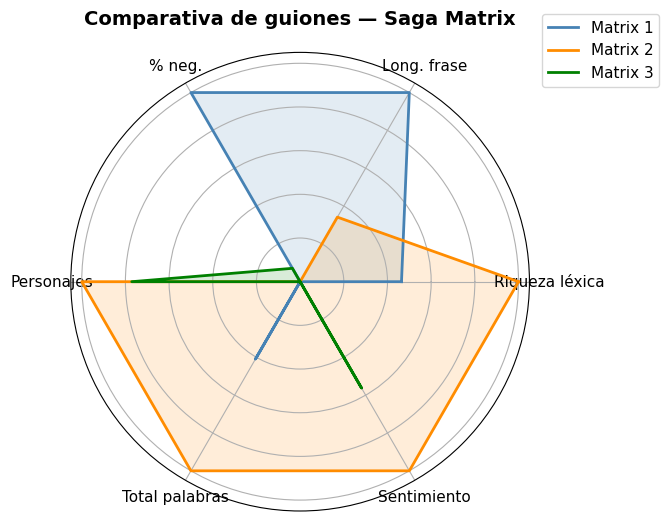

In [42]:
import numpy as np

categorias = ['Riqueza léxica', 'Long. frase', '% neg.', 'Personajes', 'Total palabras', 'Sentimiento']

valores1 = [riqueza1, matrix1['num_palabras'].mean(), pct_neg1, pers1, total1/100, matrix1['sentimiento'].mean()*100]
valores2 = [riqueza2, matrix2['num_palabras'].mean(), pct_neg2, pers2, total2/100, matrix2['sentimiento'].mean()*100]
valores3 = [riqueza3, matrix3['num_palabras'].mean(), pct_neg3, pers3, total3/100, matrix3['sentimiento'].mean()*100]

def normalizar(v1, v2, v3):
    minv, maxv = min(v1,v2,v3), max(v1,v2,v3)
    if maxv == minv:
        return 50, 50, 50
    return [(v-minv)/(maxv-minv)*100 for v in [v1,v2,v3]]

norm1, norm2, norm3 = [], [], []
for i in range(len(categorias)):
    n1, n2, n3 = normalizar(valores1[i], valores2[i], valores3[i])
    norm1.append(n1); norm2.append(n2); norm3.append(n3)

N = len(categorias)
angulos = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for vals, label, color in zip([norm1, norm2, norm3], ['Matrix 1', 'Matrix 2', 'Matrix 3'], ['steelblue', 'darkorange', 'green']):
    vals_cerrado = vals + vals[:1]
    ax.plot(angulos, vals_cerrado, color=color, linewidth=2, label=label)
    ax.fill(angulos, vals_cerrado, color=color, alpha=0.15)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Comparativa de guiones — Saga Matrix', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.show()

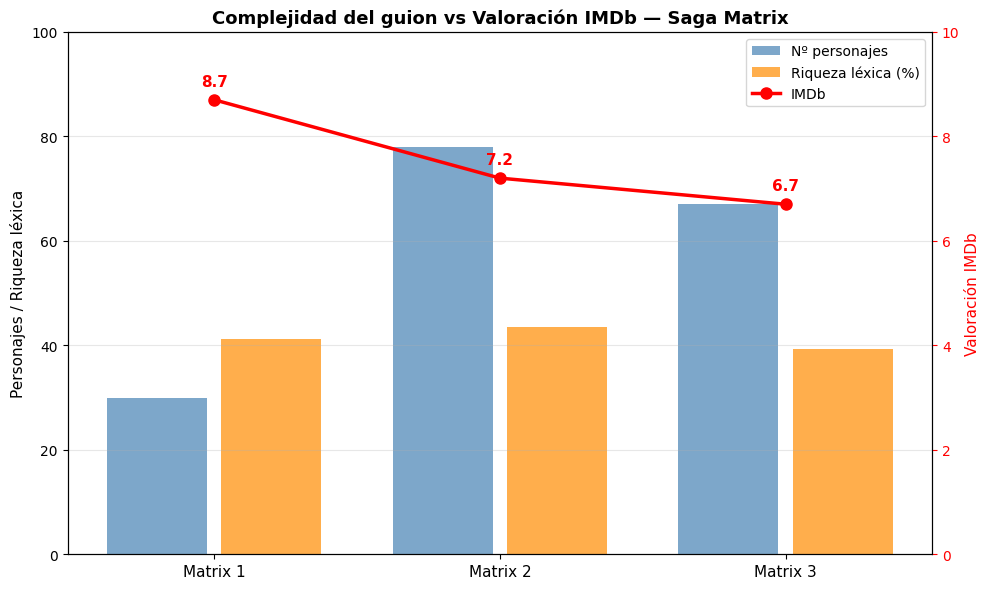

In [43]:
fig, ax1 = plt.subplots(figsize=(10, 6))

peliculas = ['Matrix 1', 'Matrix 2', 'Matrix 3']
imdb = [8.7, 7.2, 6.7]
personajes = [pers1, pers2, pers3]
riqueza = [riqueza1, riqueza2, riqueza3]

# eje izquierdo: métricas de complejidad
ax1.bar([x - 0.2 for x in range(3)], personajes, width=0.35, color='steelblue', alpha=0.7, label='Nº personajes') # barras de personajes
ax1.bar([x + 0.2 for x in range(3)], riqueza, width=0.35, color='darkorange', alpha=0.7, label='Riqueza léxica (%)') # barras de riqueza léxica
ax1.set_ylabel('Personajes / Riqueza léxica', fontsize=11)
ax1.set_xticks(range(3))
ax1.set_xticklabels(peliculas, fontsize=11)
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)

# eje derecho: valoración IMDb
ax2 = ax1.twinx() # creo un segundo eje Y compartiendo el eje X
ax2.plot(range(3), imdb, color='red', linewidth=2.5, marker='o', markersize=8, label='IMDb') # línea de valoración IMDb
ax2.set_ylabel('Valoración IMDb', fontsize=11, color='red')
ax2.set_ylim(0, 10)
ax2.tick_params(axis='y', colors='red')

# anotaciones con los valores IMDb
for i, v in enumerate(imdb):
    ax2.annotate(f'{v}', xy=(i, v), xytext=(0, 10), textcoords='offset points', ha='center', fontsize=11, color='red', fontweight='bold')

# leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels() # recojo leyendas de ambos ejes
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

ax1.set_title('Complejidad del guion vs Valoración IMDb — Saga Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Lo que sí se confirma:

El número de personajes se dispara en las secuelas (30 → 78 → 67), lo que fragmenta la narrativa y dificulta la conexión emocional del espectador.
La valoración IMDb cae progresivamente (8.7 → 7.2 → 6.7), confirmando el declive de popularidad.
La longitud de las frases disminuye, los diálogos son más cortos y fragmentados.

Lo que no se confirma del todo:

La riqueza léxica es prácticamente igual en las tres, así que el vocabulario no se volvió más complejo ni más difícil de entender.
El sentimiento emocional también es similar, no hay un tono más oscuro o difícil en las secuelas.

Conclusión honesta: Las secuelas no eran peores en calidad de escritura, pero sí más dispersas narrativamente. La explosión de personajes y tramas paralelas probablemente fue lo que desconectó al público, no la complejidad del vocabulario. La hipótesis era acertada en el fondo, aunque el factor clave no fue el lenguaje sino la estructura narrativa.